# Analisis de texto sobre reviews de productos de Amazon

Este cuaderno trabaja el corpus `ECO.csv` de reviews de productos de Amazon.

La actividad pide desplegar `CountVectorizer` sobre el texto, revisar `get_feature_names_out` y el vocabulario, medir legibilidad de cada review, aplicar preprocesamiento y luego comparar configuraciones de caracteristicas (n-gramas y otros parametros) evaluando cual deja el texto mejor preparado para machine learning.

Las preguntas de investigacion se fijan despues del EDA.


In [1]:
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display

dataset_dir = Path(kagglehub.dataset_download('pradeeshprabhakar/amazonproductreview'))
csv_path = dataset_dir / 'ECO.csv'
df = pd.read_csv(csv_path)

print(f'Ruta del archivo: {csv_path}')
print(f'Filas y columnas: {df.shape}')
print()
print('Columnas disponibles:')
print(df.columns.tolist())
print()
print('Tipos de datos:')
print(df.dtypes)
print()
print('Valores nulos por columna:')
print(df.isna().sum())
print()
print('Primeros registros:')
display(df.head())


/home/jheisonmblivecom/Academic/Deriverables/ML/nlp-amazon-reviews/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Ruta del archivo: /home/jheisonmblivecom/.cache/kagglehub/datasets/pradeeshprabhakar/amazonproductreview/versions/1/ECO.csv
Filas y columnas: (4919, 2)

Columnas disponibles:
['Index', 'Reviews']

Tipos de datos:
Index      int64
Reviews      str
dtype: object

Valores nulos por columna:
Index      0
Reviews    1
dtype: int64

Primeros registros:


,Index,Reviews
0,1,Alexa cannot hear after she starts playing
1,2,I purchased this as a birthday gift for my 7 y...
2,3,"/*Here I'm Uploading video, enjoy*/Most idioti..."
3,4,Do not buy this product. When i asked alexa t...
4,5,Its just one if the best deal i ever got on am...


Distribucion de longitud por review:


,caracteres,palabras
count,4918.000000,4918.000000
mean,109.314965,19.527654
std,156.612275,28.202909
min,1.000000,1.000000
25%,23.000000,4.000000
50%,64.000000,11.000000
75%,133.000000,24.000000
max,2124.000000,392.000000


Reviews no nulas: 4918
Reviews unicas: 4440
Duplicados exactos: 478

Reviews mas repetidas:


,frecuencia
Reviews,
Good,109
Good product,39
Nice,29
Nice product,29
Excellent,25
Very good,14
Very good product,12
good,12
Awesome,11


Cuantas reviews sobreviven a cada umbral de longitud:


,minimo_palabras,reviews,porcentaje
0,1,4918,100.0
1,3,4107,83.5
2,5,3594,73.1
3,10,2686,54.6
4,20,1519,30.9
5,50,414,8.4
6,100,104,2.1


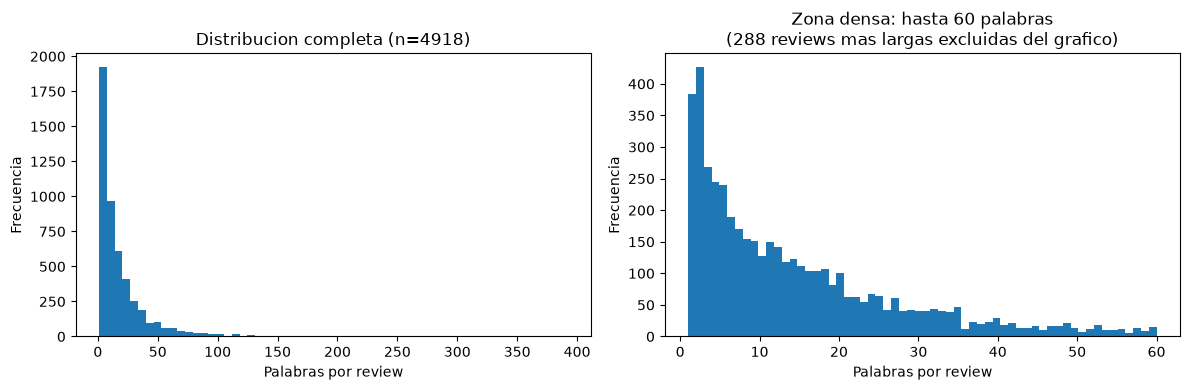

Reviews excluidas del grafico de zona densa: 288 (5.9%)


In [2]:
reviews = df['Reviews'].dropna()

longitudes = pd.DataFrame({
    'caracteres': reviews.str.len(),
    'palabras': reviews.str.split().str.len()
})

print('Distribucion de longitud por review:')
display(longitudes.describe())

print(f'Reviews no nulas: {len(reviews)}')
print(f'Reviews unicas: {reviews.nunique()}')
print(f'Duplicados exactos: {reviews.duplicated().sum()}')
print()
print('Reviews mas repetidas:')
display(reviews.value_counts().head(10).to_frame('frecuencia'))

cortes = [1, 3, 5, 10, 20, 50, 100]
cobertura = pd.DataFrame({
    'minimo_palabras': cortes,
    'reviews': [int((longitudes['palabras'] >= c).sum()) for c in cortes],
    'porcentaje': [round(100 * float((longitudes['palabras'] >= c).mean()), 1) for c in cortes]
})
print('Cuantas reviews sobreviven a cada umbral de longitud:')
display(cobertura)

corte_zoom = 60
zoom = longitudes.loc[longitudes['palabras'] <= corte_zoom, 'palabras']
excluidas = len(longitudes) - len(zoom)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(longitudes['palabras'], bins=60)
ax[0].set_xlabel('Palabras por review')
ax[0].set_ylabel('Frecuencia')
ax[0].set_title(f'Distribucion completa (n={len(longitudes)})')
ax[1].hist(zoom, bins=60)
ax[1].set_xlabel('Palabras por review')
ax[1].set_ylabel('Frecuencia')
ax[1].set_title(f'Zona densa: hasta {corte_zoom} palabras\n({excluidas} reviews mas largas excluidas del grafico)')
plt.tight_layout()
plt.show()

print(f'Reviews excluidas del grafico de zona densa: {excluidas} ({round(100 * excluidas / len(longitudes), 1)}%)')


Documentos: 4918
Terminos en el vocabulario: 6145
Celdas no nulas: 77115
Densidad de la matriz: 0.255%

Primeros 20 terminos de get_feature_names_out():
['00', '02', '03', '03036247912', '05pm', '06pm', '07', '10', '100', '1000', '1000000', '1000rs', '100mb', '100mbps', '100pc', '100s', '1064', '1073', '10alexa', '10days']

Indice de columna asignado en vocabulary_:


,indice_columna
good,2361
product,4146
alexa,400
not,3667
quality,4257


Top 25 terminos por frecuencia total:


,frecuencia,es_stopword
it,3279,True
is,2898,True
to,2470,True
the,2439,True
and,2213,True
good,1721,False
product,1539,False
alexa,1351,False
for,1338,True
not,1276,True


Tokens totales: 92771
Tokens que son stopwords: 42679 (46.0%)
Stopwords dentro del top 25: 18 de 25


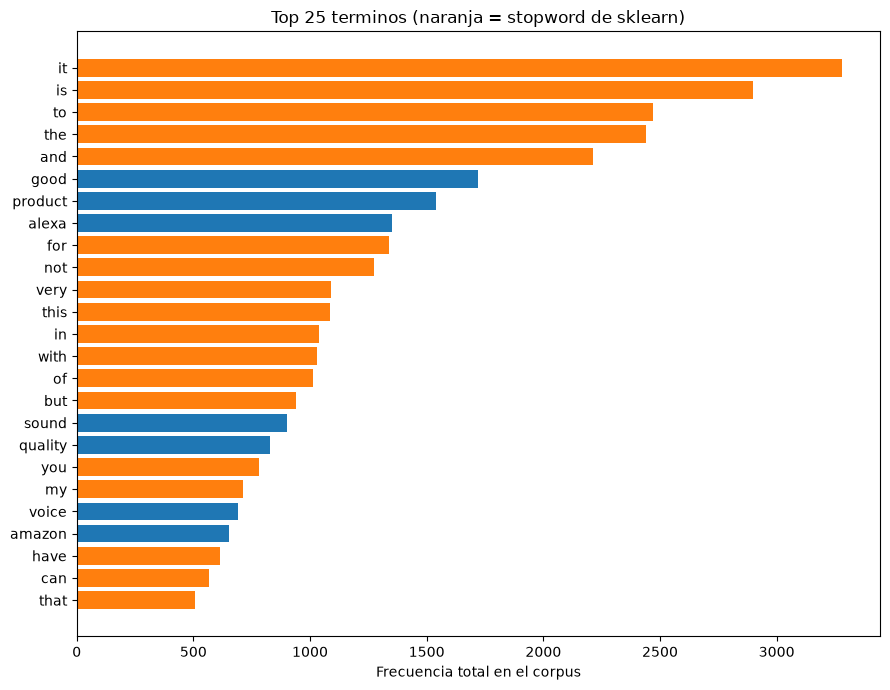

In [3]:
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS

corpus = df['Reviews'].dropna()

vectorizador = CountVectorizer()
X = vectorizador.fit_transform(corpus)
vocabulario = vectorizador.get_feature_names_out()

print(f'Documentos: {X.shape[0]}')
print(f'Terminos en el vocabulario: {X.shape[1]}')
print(f'Celdas no nulas: {X.nnz}')
print(f'Densidad de la matriz: {100 * X.nnz / (X.shape[0] * X.shape[1]):.3f}%')
print()
print('Primeros 20 terminos de get_feature_names_out():')
print(vocabulario[:20].tolist())
print()
print('Indice de columna asignado en vocabulary_:')
display(pd.Series({t: vectorizador.vocabulary_[t] for t in ['good', 'product', 'alexa', 'not', 'quality']}).to_frame('indice_columna'))

frecuencias = pd.Series(X.sum(axis=0).A1, index=vocabulario).sort_values(ascending=False)
top = frecuencias.head(25)
marcadas = pd.DataFrame({
    'frecuencia': top.values,
    'es_stopword': [t in ENGLISH_STOP_WORDS for t in top.index]
}, index=top.index)
print('Top 25 terminos por frecuencia total:')
display(marcadas)

tokens_totales = int(frecuencias.sum())
tokens_stopword = int(frecuencias[[t for t in frecuencias.index if t in ENGLISH_STOP_WORDS]].sum())
print(f'Tokens totales: {tokens_totales}')
print(f'Tokens que son stopwords: {tokens_stopword} ({100 * tokens_stopword / tokens_totales:.1f}%)')
print(f'Stopwords dentro del top 25: {int(marcadas["es_stopword"].sum())} de 25')

colores = ['tab:orange' if s else 'tab:blue' for s in marcadas['es_stopword']]
plt.figure(figsize=(9, 7))
plt.barh(marcadas.index[::-1], marcadas['frecuencia'][::-1], color=colores[::-1])
plt.xlabel('Frecuencia total en el corpus')
plt.title('Top 25 terminos (naranja = stopword de sklearn)')
plt.tight_layout()
plt.show()


## Observaciones del EDA

El dataset es minimo: un indice y una columna de texto. Toda la senal esta en `Reviews`, asi que el trabajo entero va a girar sobre esa columna.

Lo primero que salta es que **las reviews son cortisimas**. La mitad no llega a las once palabras y una cuarta parte se queda en cuatro o menos. No es un detalle de forma: las tecnicas de contexto necesitan texto donde haya contexto, y aqui buena parte del corpus no lo tiene.

Tambien hay **mucha repeticion literal**. Casi una de cada diez reviews es copia exacta de otra. En el ranking aparecen `Good`, `Good product`, `Nice`. La gente escribe asi, no es un error del dataset, pero infla las frecuencias del vocabulario.

Y hay **muchas formas de decir lo mismo**: `good`, `nice`, `excellent`, `great` viven en columnas separadas y el modelo tiene que aprender cada una por su cuenta, aunque para un lector signifiquen practicamente lo mismo.

Cuando miro el vocabulario con `CountVectorizer`, el top esta **copado por stopwords**: `it`, `is`, `to`, `the`, `and`. Casi la mitad del corpus, contado en tokens, son palabras funcionales. Las palabras con contenido aparecen recien despues.

Dos cosas que no esperaba:

- **`alexa` esta entre los terminos mas frecuentes.** Esto no son reviews de productos de Amazon en general: el corpus esta dominado por dispositivos Echo/Alexa. Lo que concluya aplica a esa familia, no al e-commerce.
- **`not` aparece muchisimo**, por encima de palabras como `sound` o `quality`. Hay negacion por todas partes, y con unigramas eso es un problema: `"not good"` y `"good"` comparten la misma columna. Ahi ya se ve por que va a valer la pena probar bigramas.

Por ultimo, el vocabulario arrastra **basura numerica** —numeros de telefono, horas, cosas como `10alexa`— ocupando columnas sin aportar nada. Y la matriz que sale es practicamente toda ceros.

### Decisiones

- Columna de trabajo: `Reviews`. Se descarta `Index` y la fila nula.
- Los duplicados exactos **se conservan**: son opiniones reales repetidas y eliminarlos cambiaria la distribucion del corpus. Queda anotado como limitacion.
- El ruido numerico se ataca con `min_df`, no eliminando digitos, para no perder precios ni modelos de producto.
- El corpus esta visiblemente sesgado a positivo: todo el top de repeticiones lo es. Cualquier evaluacion posterior tendra que tenerlo en cuenta.

### Preguntas que guiaran el analisis

- **P1: De que esta hecho realmente el vocabulario y cuanto de el es ruido?** Cuanto se limpia con preprocesamiento y filtros de frecuencia, y que se pierde en el camino.
- **P2: Que se gana y que se paga al pasar de unigramas a n-gramas?** Cuanto crece el espacio de caracteristicas, cuanto sobrevive al filtro, y si lo que queda son colocaciones con sentido.
- **P3: Que configuracion de caracteristicas deja el texto mejor preparado para modelar, y donde aporta exactamente?**


### P1: De que esta hecho realmente el vocabulario y cuanto de el es ruido?

Antes de traer ninguna libreria quiero saber cuanto se limpia solo moviendo parametros del propio `CountVectorizer`. Son dos: `stop_words`, que elimina palabras funcionales, y `min_df`, que descarta terminos presentes en muy pocos documentos.

Comparo las cuatro combinaciones. Y no miro solo cuanto encoge el vocabulario, porque encoger es facil: miro tambien cuantos documentos se quedan sin ninguna caracteristica, que es el precio escondido de todo filtro.


In [4]:
configuraciones = {
    'base': dict(),
    'sin stopwords': dict(stop_words='english'),
    'min_df=5': dict(min_df=5),
    'sin stopwords + min_df=5': dict(stop_words='english', min_df=5),
}

resumen = []
vocabularios = {}
for nombre, params in configuraciones.items():
    vec = CountVectorizer(**params)
    M = vec.fit_transform(corpus)
    terminos = vec.get_feature_names_out()
    vocabularios[nombre] = terminos
    con_digitos = sum(1 for t in terminos if any(c.isdigit() for c in t))
    resumen.append({
        'configuracion': nombre,
        'vocabulario': M.shape[1],
        'tokens_retenidos': int(M.sum()),
        'densidad_%': round(100 * M.nnz / (M.shape[0] * M.shape[1]), 3),
        'terminos_con_digitos': con_digitos,
        'docs_vacios': int((M.sum(axis=1).A1 == 0).sum()),
    })

resumen = pd.DataFrame(resumen).set_index('configuracion')
print('Efecto de los parametros del CountVectorizer sobre el vocabulario:')
display(resumen)

print('Top 10 terminos de cada configuracion:')
tops = {}
for nombre, params in configuraciones.items():
    vec = CountVectorizer(**params)
    M = vec.fit_transform(corpus)
    f = pd.Series(M.sum(axis=0).A1, index=vec.get_feature_names_out()).sort_values(ascending=False)
    tops[nombre] = f.head(10).index.tolist()
display(pd.DataFrame(tops))

base = set(vocabularios['base'])
filtrado = set(vocabularios['sin stopwords + min_df=5'])
print(f'Terminos eliminados por el filtrado: {len(base - filtrado)}')
print(f'Terminos conservados: {len(filtrado)}')
print()
print('Terminos eliminados por el filtrado, ordenados por frecuencia en el corpus:')
frec_base = pd.Series(X.sum(axis=0).A1, index=vocabulario)
eliminados = frec_base[list(base - filtrado)].sort_values(ascending=False)
display(eliminados.head(15).to_frame('frecuencia_en_corpus'))
print('Nota: alta frecuencia no implica contenido. Lo relevante de esta lista es que aparecen not, but y very.')


Efecto de los parametros del CountVectorizer sobre el vocabulario:


,vocabulario,tokens_retenidos,densidad_%,terminos_con_digitos,docs_vacios
configuracion,,,,,
base,6145,92771,0.255,305,20
sin stopwords,5886,50092,0.157,305,38
min_df=5,1403,85511,1.017,26,59
sin stopwords + min_df=5,1189,42923,0.659,26,94


Top 10 terminos de cada configuracion:


,base,sin stopwords,min_df=5,sin stopwords + min_df=5
0,it,good,it,good
1,is,product,is,product
2,to,alexa,to,alexa
3,the,sound,the,sound
4,and,quality,and,quality
5,good,voice,good,voice
6,product,amazon,product,amazon
7,alexa,device,alexa,device
8,for,nice,for,smart
9,not,smart,not,nice


Terminos eliminados por el filtrado: 4956
Terminos conservados: 1189

Terminos eliminados por el filtrado, ordenados por frecuencia en el corpus:


,frecuencia_en_corpus
it,3279
is,2898
to,2470
the,2439
and,2213
for,1338
not,1276
very,1089
this,1085
in,1037


Nota: alta frecuencia no implica contenido. Lo relevante de esta lista es que aparecen not, but y very.


### P1.1b: la lista de stopwords borra la negacion (refinamiento)

Quitar stopwords es de lejos el filtro mas rentable: toca pocos terminos y se lleva casi la mitad del corpus. El problema aparece al mirar **cuales** se lleva. En la lista de eliminados estan `not`, `but` y `very`.

Justamente las que voltean o intensifican lo que viene despues. `"not good"` sin stopwords queda en `"good"`, que significa lo contrario.

Tiene explicacion. Esa lista viene del mundo de los buscadores, donde se borraban las palabras vacias para ahorrar espacio de indice y porque no ayudan a emparejar un documento con una consulta. Para saber *de que trata* un texto, `not` no aporta nada. Pero la opinion vive justamente en esas palabras: la lista esta bien hecha para una tarea que no es la mia.

La salida no es renunciar al filtro sino personalizarlo. Parto de la lista de sklearn y le devuelvo los marcadores de negacion e intensidad.


In [5]:
conservar = {
    'not', 'no', 'nor', 'never', 'none', 'nothing', 'cannot', 'without', 'against',
    'but', 'however', 'very', 'too', 'only', 'few', 'less', 'more', 'most',
    'well', 'rather', 'still', 'yet', 'although', 'though'
}
stopwords_propias = sorted(ENGLISH_STOP_WORDS - conservar)

print(f'Stopwords de sklearn: {len(ENGLISH_STOP_WORDS)}')
print(f'Marcadores devueltos al vocabulario: {len(conservar)}')
print(f'Lista propia: {len(stopwords_propias)}')
print()

comparacion = {
    'base': dict(),
    'stopwords sklearn': dict(stop_words='english'),
    'stopwords propias': dict(stop_words=stopwords_propias),
    'stopwords propias + min_df=5': dict(stop_words=stopwords_propias, min_df=5),
}

filas = []
for nombre, params in comparacion.items():
    vec = CountVectorizer(**params)
    M = vec.fit_transform(corpus)
    terminos = set(vec.get_feature_names_out())
    filas.append({
        'configuracion': nombre,
        'vocabulario': M.shape[1],
        'tokens_retenidos': int(M.sum()),
        'docs_vacios': int((M.sum(axis=1).A1 == 0).sum()),
        'conserva_not': 'not' in terminos,
        'conserva_but': 'but' in terminos,
        'conserva_the': 'the' in terminos,
    })

display(pd.DataFrame(filas).set_index('configuracion'))

vec = CountVectorizer(stop_words=stopwords_propias, min_df=5)
M = vec.fit_transform(corpus)
frecuencias_propias = pd.Series(M.sum(axis=0).A1, index=vec.get_feature_names_out()).sort_values(ascending=False)
print('Top 20 con la lista propia:')
display(frecuencias_propias.head(20).to_frame('frecuencia'))


Stopwords de sklearn: 318
Marcadores devueltos al vocabulario: 24
Lista propia: 294



,vocabulario,tokens_retenidos,docs_vacios,conserva_not,conserva_but,conserva_the
configuracion,,,,,,
base,6145,92771,20,True,True,True
stopwords sklearn,5886,50092,38,False,False,False
stopwords propias,5909,55364,27,True,True,False
stopwords propias + min_df=5,1211,48193,76,True,True,False


Top 20 con la lista propia:


,frecuencia
good,1721
product,1539
alexa,1351
not,1276
very,1089
but,940
sound,903
quality,830
voice,691
amazon,651


### P1.2: aporta algo lematizar despues de `min_df`? (refinamiento)

`min_df` ya recorto el vocabulario a una fraccion de lo que era. La lematizacion atacaria lo que quedo en pie: pares como `product` / `products`, que siguen ocupando dos columnas.

Mi intuicion es que despues de ese corte queda poco por ganar, porque las variantes raras ya cayeron. Pero es una intuicion, y la unica forma de saberlo es medirla. Lematizo con spaCy y comparo el mismo filtro sobre el corpus original y sobre el lematizado.


In [6]:
import spacy
import time

nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])

inicio = time.time()
corpus_lema = pd.Series(
    [' '.join(t.lemma_.lower() for t in doc if t.is_alpha or t.like_num)
     for doc in nlp.pipe(corpus, batch_size=200)],
    index=corpus.index
)
print(f'Lematizacion de {len(corpus)} documentos en {time.time() - inicio:.1f} s')
print()

ejemplos = pd.DataFrame({'original': corpus.head(5).values, 'lematizado': corpus_lema.head(5).values})
display(ejemplos)

filas = []
for nombre, texto in [('sin lematizar', corpus), ('lematizado', corpus_lema)]:
    for etiqueta, params in [('propias', dict(stop_words=stopwords_propias)),
                             ('propias + min_df=5', dict(stop_words=stopwords_propias, min_df=5))]:
        vec = CountVectorizer(**params)
        M = vec.fit_transform(texto)
        filas.append({
            'corpus': nombre,
            'filtro': etiqueta,
            'vocabulario': M.shape[1],
            'tokens': int(M.sum()),
            'docs_vacios': int((M.sum(axis=1).A1 == 0).sum()),
        })
display(pd.DataFrame(filas).set_index(['corpus', 'filtro']))

vec_a = CountVectorizer(stop_words=stopwords_propias, min_df=5).fit(corpus)
vec_b = CountVectorizer(stop_words=stopwords_propias, min_df=5).fit(corpus_lema)
solo_sin_lema = sorted(set(vec_a.get_feature_names_out()) - set(vec_b.get_feature_names_out()))
print(f'Terminos que desaparecen al lematizar: {len(solo_sin_lema)}')
print(solo_sin_lema[:40])


Lematizacion de 4918 documentos en 5.3 s



,original,lematizado
0,Alexa cannot hear after she starts playing,alexa can not hear after she start play
1,I purchased this as a birthday gift for my 7 y...,i purchase this as a birthday gift for my 7 ye...
2,"/*Here I'm Uploading video, enjoy*/Most idioti...",i upload video idiotic device i every buy neve...
3,Do not buy this product. When i asked alexa t...,do not buy this product when i ask alexa that ...
4,Its just one if the best deal i ever got on am...,its just one if the good deal i ever get on am...


vocabulario  tokens  docs_vacios
corpus        filtro                                              
sin lematizar propias                    5909   55364           27
              propias + min_df=5         1211   48193           76
lematizado    propias                    4656   52863           41
              propias + min_df=5          998   47333           84

Terminos que desaparecen al lematizar: 352
['2020', '2021', '2k', '5k', '99', 'according', 'activities', 'acts', 'added', 'adding', 'advertised', 'alarms', 'answering', 'answers', 'appliances', 'apps', 'arrived', 'asked', 'asking', 'asks', 'attached', 'based', 'bigger', 'biggest', 'blinking', 'blowing', 'books', 'bored', 'boring', 'bought', 'brought', 'built', 'bulbs', 'called', 'calling', 'calls', 'came', 'cannot', 'capabilities', 'cases']


### Cierre de P1: de que esta hecho el vocabulario y cuanto es ruido

Muy poco del vocabulario crudo es vocabulario util.

Casi la mitad del corpus, contado en tokens, son stopwords, y las aporta apenas un punado de terminos. Esa es la asimetria central: **pocos tipos de palabra, muchisimas ocurrencias**. Por eso quitar stopwords se lleva medio corpus sin casi tocar el tamano del vocabulario.

`min_df` hace el trabajo contrario, y es el que de verdad reduce el vocabulario: elimina tres cuartas partes de los terminos y apenas roza el volumen de texto, porque lo que borra son terminos que aparecian en una o dos reviews. De paso resuelve casi solo el ruido numerico. Lo interesante es **que sobrevive**: precios, anos, cosas como `2k` y `5k`, que en reviews de producto si dicen algo. Por eso no elimine los digitos por regla; el filtro de frecuencia limpia sin destruir.

Sobre que se pierde en el camino, que era la otra mitad de la pregunta:

- La lista de stopwords por defecto **borra la negacion**. Con la lista propia recupero `not` y `but`, gano bastante texto de vuelta y ademas quedan menos documentos vacios.
- **Los documentos vacios son el costo real del filtrado.** Cada filtro que aprieto deja mas reviews como filas de puros ceros, y son casi siempre las mismas: las de una o dos palabras que el EDA ya habia senalado. Ningun modelo puede hacer nada con ellas.
- La lematizacion, aplicada **despues** de `min_df`, reduce bastante menos de lo que esperaba. El filtro de frecuencia ya se habia comido casi todo el efecto, porque las variantes flexivas son raras por naturaleza y ya habian caido.

Lo que si cambia de forma visible es el top del vocabulario: deja de ser una lista de conectores y pasa a ser el dominio real, con `good`, `product`, `alexa`, `not`, `sound`, `quality`, `voice`, `speaker`, `echo`. Ahi es donde se ve que el corpus es de dispositivos Echo/Alexa y no de productos de Amazon en general.

**Lo que la lematizacion no resuelve:** trabaja sobre formas de una misma palabra, no sobre significados parecidos. `good`, `nice`, `excellent` y `great` tienen lemas distintos y siguen siendo columnas independientes. La fragmentacion que note desde el EDA sigue intacta.

Como el efecto resulto pequeno y ademas cuesta documentos vacios, no adopto la lematizacion como paso obligatorio. Pasa a ser **una configuracion mas a comparar**, en lugar de una decision tomada por intuicion.


## P2: que se gana y que se paga al pasar de unigramas a n-gramas?

Con unigramas, `"not good"` y `"good"` comparten la columna `good`. La bolsa de palabras pierde el orden, y con el orden pierde la negacion. Un n-grama es simplemente una secuencia de n palabras contiguas, y convertir `not good` en **una sola columna** es la forma mas directa de devolverle algo de contexto al modelo.

El corpus da un motivo para intentarlo: `not` es de las palabras mas frecuentes que quedan tras el filtrado. Hay muchisima negacion que los unigramas no pueden interpretar.

Pero cada n-grama nuevo es una columna nueva, y la matriz de unigramas ya es practicamente toda ceros. Antes de celebrar nada, el precio: cuanto crece el espacio, cuanto de ese crecimiento es basura que aparece una sola vez, y cuanto sobrevive al filtro que P1 dejo montado.


Costo de subir el orden del n-grama:


vocabulario  en_un_solo_doc_%  densidad_%  docs_vacios
ngram_range filtro                                                            
(1, 1)      sin min_df         5909              57.3      0.1713           27
            min_df=5           1211               0.0      0.7205           76
(1, 2)      sin min_df        38195              80.9      0.0530           27
            min_df=5           2173               0.0      0.5236           76
(2, 2)      sin min_df        32286              85.2      0.0314          513
            min_df=5            962               0.0      0.2758         1212
(1, 3)      sin min_df        80370              88.9      0.0368           27
            min_df=5           2375               0.0      0.4967           76

filtro,min_df=5,sin min_df
ngram_range,,
"(1, 1)",1211,5909
"(1, 2)",2173,38195
"(2, 2)",962,32286
"(1, 3)",2375,80370


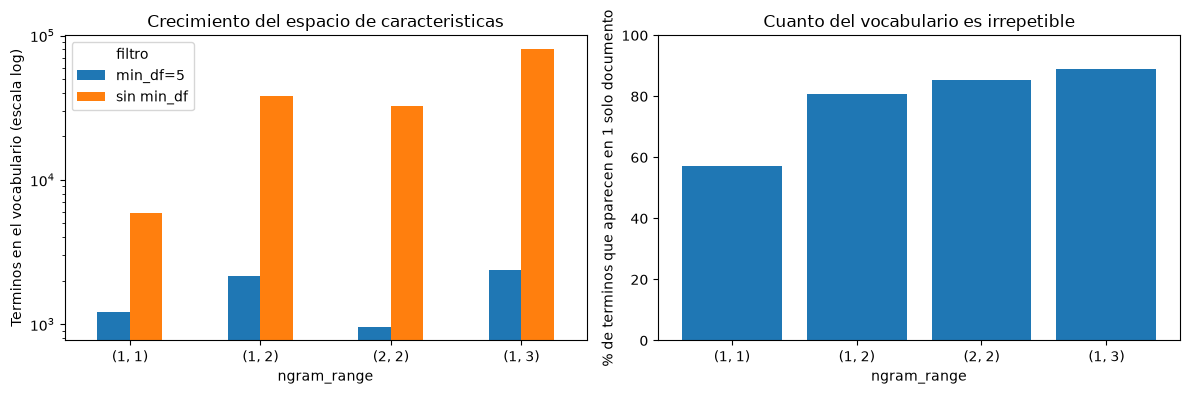

In [7]:
rangos = [(1, 1), (1, 2), (2, 2), (1, 3)]
filtros = [
    ('sin min_df', dict(stop_words=stopwords_propias)),
    ('min_df=5', dict(stop_words=stopwords_propias, min_df=5)),
]

filas = []
for rango in rangos:
    for etiqueta, params in filtros:
        vec = CountVectorizer(ngram_range=rango, **params)
        M = vec.fit_transform(corpus)
        docs_por_termino = (M > 0).sum(axis=0).A1
        hapax = int((docs_por_termino == 1).sum())
        filas.append({
            'ngram_range': str(rango),
            'filtro': etiqueta,
            'vocabulario': M.shape[1],
            'en_un_solo_doc_%': round(100 * hapax / M.shape[1], 1),
            'densidad_%': round(100 * M.nnz / (M.shape[0] * M.shape[1]), 4),
            'docs_vacios': int((M.sum(axis=1).A1 == 0).sum()),
        })

tabla = pd.DataFrame(filas)
print('Costo de subir el orden del n-grama:')
display(tabla.set_index(['ngram_range', 'filtro']))

pivote = tabla.pivot(index='ngram_range', columns='filtro', values='vocabulario').loc[[str(r) for r in rangos]]
display(pivote)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
pivote.plot(kind='bar', ax=ax[0], logy=True)
ax[0].set_ylabel('Terminos en el vocabulario (escala log)')
ax[0].set_xlabel('ngram_range')
ax[0].set_title('Crecimiento del espacio de caracteristicas')
ax[0].tick_params(axis='x', rotation=0)

sin_filtro = tabla[tabla['filtro'] == 'sin min_df']
ax[1].bar(sin_filtro['ngram_range'], sin_filtro['en_un_solo_doc_%'])
ax[1].set_ylabel('% de terminos que aparecen en 1 solo documento')
ax[1].set_xlabel('ngram_range')
ax[1].set_title('Cuanto del vocabulario es irrepetible')
ax[1].set_ylim(0, 100)
plt.tight_layout()
plt.show()


### P2.1: que son los bigramas que sobreviven?

El filtro deja pasar una fraccion minima de los bigramas. Ese porcentaje por si solo no distingue entre dos situaciones opuestas: que los bigramas no sirvan en este corpus, o que el filtro este haciendo bien su trabajo y lo que queda sea un destilado. Para saberlo hay que mirar **cuales** son.


Bigramas que sobreviven a min_df=5: 962

Top 30 bigramas:


,frecuencia
sound quality,541
voice recognition,293
echo dot,274
very good,273
good product,246
good but,151
nice product,148
not good,112
very nice,110
not working,107


Bigramas que arrancan con un marcador de negacion: 66


,frecuencia
not good,112
not working,107
not able,46
no battery,31
not worth,25
not connecting,23
not available,21
not satisfied,18
not happy,17
not great,16


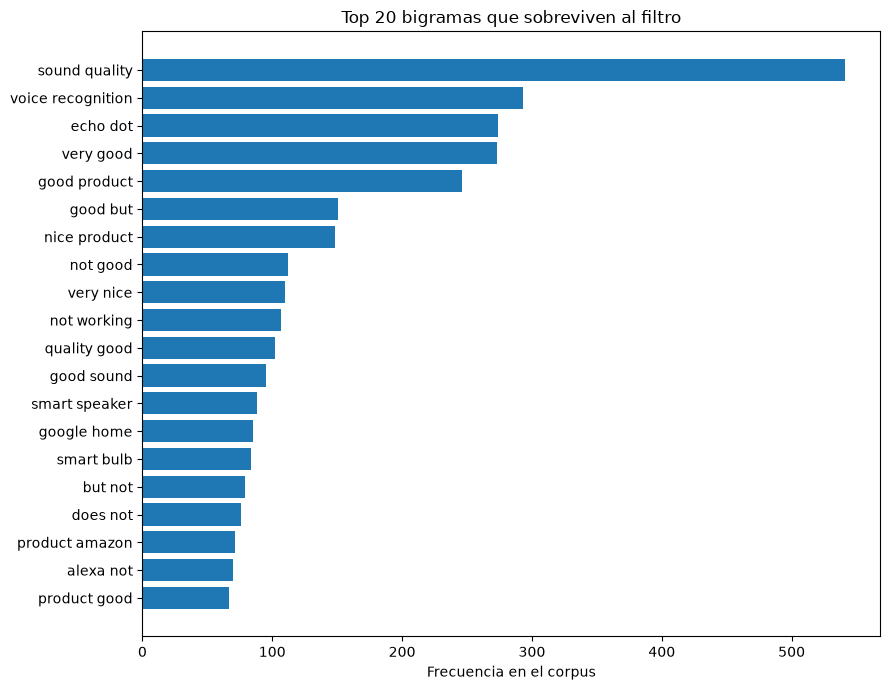

In [8]:
vec_n = CountVectorizer(ngram_range=(1, 2), stop_words=stopwords_propias, min_df=5)
Mn = vec_n.fit_transform(corpus)
terminos_n = vec_n.get_feature_names_out()
frecuencias_n = pd.Series(Mn.sum(axis=0).A1, index=terminos_n)

bigramas = frecuencias_n[[t for t in terminos_n if ' ' in t]].sort_values(ascending=False)
print(f'Bigramas que sobreviven a min_df=5: {len(bigramas)}')
print()
print('Top 30 bigramas:')
display(bigramas.head(30).to_frame('frecuencia'))

negadores = {'not', 'no', 'never', 'cannot', 'without', 'nothing'}
con_negacion = bigramas[[b for b in bigramas.index if b.split()[0] in negadores]]
print(f'Bigramas que arrancan con un marcador de negacion: {len(con_negacion)}')
display(con_negacion.head(20).to_frame('frecuencia'))

plt.figure(figsize=(9, 7))
top20 = bigramas.head(20)
plt.barh(top20.index[::-1], top20.values[::-1])
plt.xlabel('Frecuencia en el corpus')
plt.title('Top 20 bigramas que sobreviven al filtro')
plt.tight_layout()
plt.show()


### Cierre de P2: los bigramas acompanan, no reemplazan

**Lo que se paga.** Subir el orden del n-grama multiplica el espacio de caracteristicas, y multiplica todavia mas rapido la basura. Con trigramas, nueve de cada diez columnas aparecen en un solo documento: no pueden generalizar a nada.

**Lo que sobrevive.** El filtro deja pasar apenas un 3% de los bigramas. Parece una masacre, pero al mirar cuales son queda claro que destilo en vez de destruir. Salen tres familias:

- **Colocaciones de dominio**: `sound quality`, `voice recognition`, `echo dot`, `smart speaker`, `google home`, `value money`. Son conceptos, no pares casuales. `sound` y `quality` por separado no significan calidad de sonido.
- **Negacion**: `not good`, `not working`, `not able`, `no battery`, `not worth`, `not satisfied`, `not happy`. Esto es exactamente lo que los unigramas no pueden representar. Hay un monton de reviews donde `good` aparece **negado**, y con unigramas solos esas reviews le suman evidencia positiva al modelo.
- **Contraste e intensidad**: `very good`, `very nice`, `good but`, `but not`. `good but` es un positivo con reserva que los unigramas leen como positivo puro.

Y aqui hay algo que vale mas que el resultado: esos bigramas de negacion y contraste **existen solo porque en P1.1b decidi conservar `not` y `but`**. Con la lista de stopwords por defecto habrian desaparecido todos, y esta pregunta habria concluido que los bigramas no aportan nada. Una decision de preprocesamiento determino el resultado de la vectorizacion.

**Lo que no funciona.**

- Usar bigramas **solos**, sin unigramas, deja uno de cada cuatro documentos vacio. Son las reviews de una o dos palabras, que no producen ningun bigrama. Combinando unigramas y bigramas, los documentos vacios se quedan igual que antes: el unigrama mantiene viva la fila. Los bigramas **acompanan**, no reemplazan.
- Los trigramas casi no sobreviven al filtro. Con una mediana de once palabras por review no hay material para ellos, y lo poco que queda no compensa el tamano que hay que pagar en crudo.

**Conclusion de P2.** Unigramas mas bigramas con `min_df` es la unica ampliacion que se sostiene: recupera negacion y colocaciones sin dejar reviews sin representar. Que ademas **mejore la clasificacion** es otra afirmacion, y esta pregunta no puede responderla: hasta aqui solo describi el espacio de caracteristicas, no medi nada contra un objetivo.


## P3: que configuracion deja el texto mejor preparado para modelar, y donde aporta?

Aqui hay que ser explicito con el alcance, porque "mejor preparado" no significa nada si no se dice para que y medido como.

El veredicto definitivo sobre una configuracion exige entrenar un modelo y comparar metricas sobre datos que no vio. Este cuaderno no lo hace, y la razon esta al final de esta seccion. **Esa parte se deja fuera de alcance y corresponde a un cuaderno aparte.**

Lo que si se puede decidir sin etiqueta es cual configuracion entrega una matriz mejor construida. Tres criterios, todos medibles sobre la matriz misma:

1. **Cobertura**: cuantos documentos quedan sin ninguna caracteristica. Una fila de puros ceros es un documento que ningun modelo podra usar, sea cual sea el modelo.
2. **Compacidad**: cuantas columnas cuesta, y que proporcion de ellas aparece en un solo documento. Las columnas irrepetibles son peso muerto.
3. **Retencion de senal**: si las caracteristicas que ya sabemos relevantes en este corpus —negacion, colocaciones, intensificadores— sobreviven o se pierden.

Antes de armar esa comparacion queda un punto del enunciado sin cubrir: el test de legibilidad, que es una caracteristica derivada del texto y no sale de la bolsa de palabras.


Distribucion de los indices de legibilidad:


,palabras,flesch,grado_fk
count,4918.000000,4918.000000,4918.000000
mean,19.527654,66.279815,6.178851
std,28.202909,31.680206,5.098998
min,1.000000,-217.180000,-3.400000
25%,4.000000,52.873426,3.267183
50%,11.000000,69.352086,5.893110
75%,24.000000,81.855000,8.548529
max,392.000000,121.220000,47.030000


Reviews con Flesch fuera del rango teorico 0-100: 719 (14.6%)



,review,palabras,flesch,grado_fk
0,Wow,1,121.220,-3.400000
1,Superb..,1,36.620,8.400000
2,Not as expected,3,62.790,5.246667
3,Awesome product,2,35.605,8.790000
4,Very good,2,77.905,2.890000
5,Not upto expectation,3,6.390,13.113333


Flesch por tramo de longitud:


,count,mean,std,min,max
palabras,,,,,
"(0, 3]",1079,66.6,53.7,-217.2,121.2
"(3, 5]",485,66.0,33.6,-72.2,119.2
"(5, 10]",795,67.8,25.2,-39.0,119.2
"(10, 20]",1141,66.2,19.3,-40.6,118.2
"(20, 50]",1017,65.7,15.4,-5.0,100.8
"(50, 400]",401,64.5,16.7,-31.9,95.9


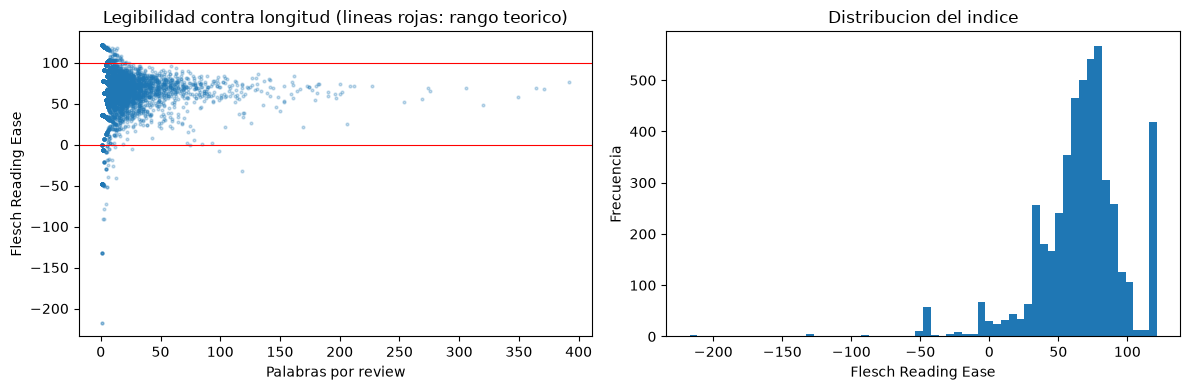

In [9]:
import textstat

legibilidad = pd.DataFrame({
    'palabras': corpus.str.split().str.len(),
    'flesch': corpus.map(textstat.flesch_reading_ease),
    'grado_fk': corpus.map(textstat.flesch_kincaid_grade),
})

print('Distribucion de los indices de legibilidad:')
display(legibilidad.describe())

fuera_rango = int(((legibilidad['flesch'] < 0) | (legibilidad['flesch'] > 100)).sum())
print(f'Reviews con Flesch fuera del rango teorico 0-100: {fuera_rango} ({100 * fuera_rango / len(legibilidad):.1f}%)')
print()

muestra = corpus[corpus.str.split().str.len() <= 3].head(6)
display(pd.DataFrame({
    'review': muestra.values,
    'palabras': muestra.str.split().str.len().values,
    'flesch': muestra.map(textstat.flesch_reading_ease).values,
    'grado_fk': muestra.map(textstat.flesch_kincaid_grade).values,
}))

tramos = pd.cut(legibilidad['palabras'], [0, 3, 5, 10, 20, 50, 400])
resumen_tramos = legibilidad.groupby(tramos, observed=True)['flesch'].agg(['count', 'mean', 'std', 'min', 'max']).round(1)
print('Flesch por tramo de longitud:')
display(resumen_tramos)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].scatter(legibilidad['palabras'], legibilidad['flesch'], s=4, alpha=0.25)
ax[0].axhline(0, color='red', linewidth=0.8)
ax[0].axhline(100, color='red', linewidth=0.8)
ax[0].set_xlabel('Palabras por review')
ax[0].set_ylabel('Flesch Reading Ease')
ax[0].set_title('Legibilidad contra longitud (lineas rojas: rango teorico)')
ax[1].hist(legibilidad['flesch'], bins=60)
ax[1].set_xlabel('Flesch Reading Ease')
ax[1].set_ylabel('Frecuencia')
ax[1].set_title('Distribucion del indice')
plt.tight_layout()
plt.show()


### P3.1: la legibilidad es fiable solo en la cola larga

Un indice de legibilidad toma una review y devuelve un numero que estima cuanto cuesta leerla. Flesch se apoya en dos ideas nada mas: oraciones largas cuestan mas, y palabras largas cuestan mas. No mira significado. Dentro del pipeline es **una caracteristica mas**: una columna densa que se pega al lado de la matriz del vectorizador y aporta algo que los conteos no capturan, que es *como* esta escrito el texto y no *de que* habla.

Esperaba que el indice estuviera sesgado por la longitud de la review. **No lo esta.** La media se mantiene practicamente igual en todos los tramos de longitud, y la correlacion entre numero de palabras e indice es basicamente cero.

Lo que se rompe no es la media sino la **precision**. En las reviews mas cortas el indice se dispara en todas direcciones alrededor de una media correcta, y una parte del corpus termina fuera del rango teorico del indicador. A medida que las reviews se alargan, la dispersion se reduce a un tercio.

La razon esta en la formula: divide entre el numero de oraciones. `"Good"` es una palabra en una oracion, y el resultado se va por encima del techo de la escala. Una review larga sin un solo punto hace explotar esa division y se va muy por debajo del piso. Flesch se diseno para parrafos de prosa continua, no para fragmentos de una a cuatro palabras.

**Mi lectura:** el indice no esta roto, esta mal aplicado a la mitad corta del corpus. Es fiable para las reviews largas, que son la minoria, y entrega ruido centrado para el resto. Un modelo que reciba esta columna no tiene como distinguir cual de los dos casos esta leyendo, asi que meterla tal cual introduce ruido en la mayoria de las filas. Si la usara, tendria que ir acompanada de otra columna que diga si la review es lo bastante larga como para que el numero signifique algo.

Es un hallazgo sobre el corpus, no sobre la tecnica: el test esta bien construido, lo que pasa es que este corpus no tiene el tipo de texto que el test necesita.


### P3.2: barrido de configuraciones evaluado sin etiqueta

Comparo ocho configuraciones del `CountVectorizer`, desde la base sin ningun parametro hasta combinaciones de lista propia de stopwords, filtros de frecuencia, bigramas, lematizacion y tope de caracteristicas. Cada una se evalua con los tres criterios de arriba: cobertura, compacidad y retencion de senal.


Comparacion de configuraciones sin etiqueta:


,vocabulario,docs_vacios,en_un_solo_doc_%,cols_para_80%_tokens,conserva_not,bigramas_negacion
configuracion,,,,,,
1. base,6145,20,55.4,416,True,0
2. stopwords sklearn,5886,38,57.6,749,False,0
3. stopwords propias,5909,27,57.3,664,True,0
4. propias + min_df=5,1211,76,0.0,318,True,0
"5. 4 + ngram (1,2)",2173,76,0.0,654,True,66
6. 5 + max_df=0.5,2173,76,0.0,654,True,66
7. 5 + lematizado,2079,84,0.0,573,True,67
8. 5 + max_features=1000,1000,93,0.0,359,True,26


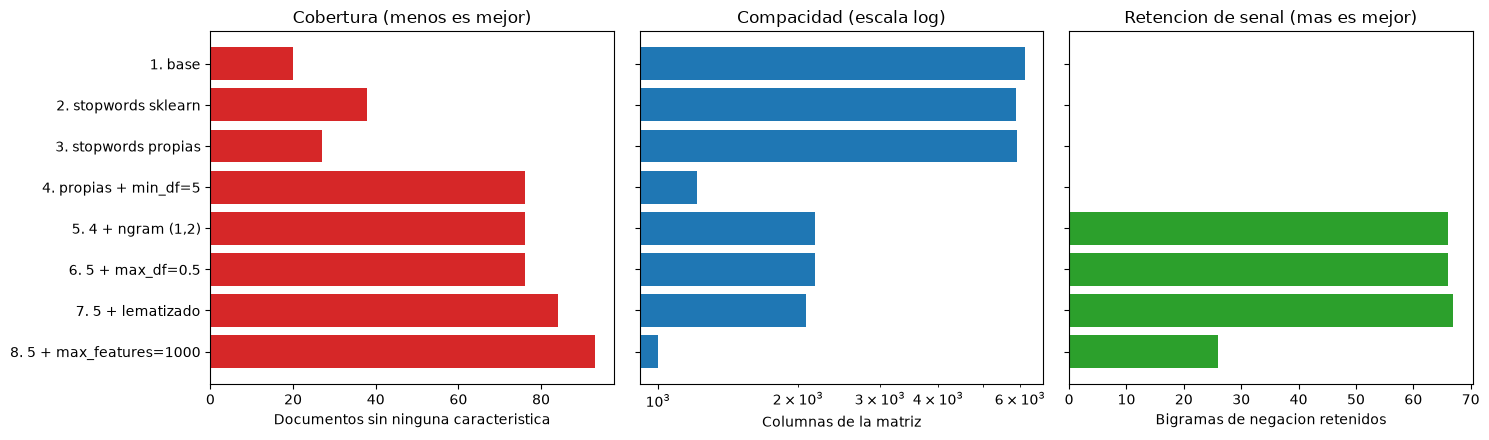

In [10]:
negadores = {'not', 'no', 'never', 'cannot', 'without', 'nothing', 'nor'}

def evaluar(nombre, texto, **params):
    vec = CountVectorizer(**params)
    M = vec.fit_transform(texto)
    terminos = vec.get_feature_names_out()
    frec = pd.Series(M.sum(axis=0).A1, index=terminos).sort_values(ascending=False)
    acumulado = frec.cumsum() / frec.sum()
    docs_por_termino = (M > 0).sum(axis=0).A1
    bigramas_neg = [t for t in terminos if ' ' in t and t.split()[0] in negadores]
    return {
        'configuracion': nombre,
        'vocabulario': M.shape[1],
        'docs_vacios': int((M.sum(axis=1).A1 == 0).sum()),
        'en_un_solo_doc_%': round(100 * float((docs_por_termino == 1).mean()), 1),
        'cols_para_80%_tokens': int((acumulado < 0.8).sum() + 1),
        'conserva_not': 'not' in set(terminos),
        'bigramas_negacion': len(bigramas_neg),
    }

sp = stopwords_propias
resultados = [
    evaluar('1. base', corpus),
    evaluar('2. stopwords sklearn', corpus, stop_words='english'),
    evaluar('3. stopwords propias', corpus, stop_words=sp),
    evaluar('4. propias + min_df=5', corpus, stop_words=sp, min_df=5),
    evaluar('5. 4 + ngram (1,2)', corpus, stop_words=sp, min_df=5, ngram_range=(1, 2)),
    evaluar('6. 5 + max_df=0.5', corpus, stop_words=sp, min_df=5, max_df=0.5, ngram_range=(1, 2)),
    evaluar('7. 5 + lematizado', corpus_lema, stop_words=sp, min_df=5, ngram_range=(1, 2)),
    evaluar('8. 5 + max_features=1000', corpus, stop_words=sp, min_df=5, ngram_range=(1, 2), max_features=1000),
]

comparacion = pd.DataFrame(resultados).set_index('configuracion')
print('Comparacion de configuraciones sin etiqueta:')
display(comparacion)

fig, ax = plt.subplots(1, 3, figsize=(15, 4.5))
ax[0].barh(comparacion.index[::-1], comparacion['docs_vacios'][::-1], color='tab:red')
ax[0].set_xlabel('Documentos sin ninguna caracteristica')
ax[0].set_title('Cobertura (menos es mejor)')
ax[1].barh(comparacion.index[::-1], comparacion['vocabulario'][::-1], color='tab:blue')
ax[1].set_xlabel('Columnas de la matriz')
ax[1].set_xscale('log')
ax[1].set_title('Compacidad (escala log)')
ax[2].barh(comparacion.index[::-1], comparacion['bigramas_negacion'][::-1], color='tab:green')
ax[2].set_xlabel('Bigramas de negacion retenidos')
ax[2].set_title('Retencion de senal (mas es mejor)')
for a in ax[1:]:
    a.set_yticklabels([])
plt.tight_layout()
plt.show()


### Cierre de P3: la configuracion que se sostiene

La configuracion **5** —lista propia de stopwords, `min_df=5` y `ngram_range=(1,2)`— es la que mejor queda en los tres criterios a la vez. Mantiene la misma cobertura que los unigramas solos, no arrastra ni una columna que aparezca en un unico documento, y es la unica que conserva la negacion junto con las colocaciones de dominio. Los bigramas cuestan menos columnas de las que aportan.

**Dos hallazgos sobre los parametros que no esperaba:**

`max_df=0.5` es **completamente inerte** aqui. La configuracion 6 sale identica a la 5, fila por fila. Una vez fuera las stopwords, ningun termino aparece en mas de la mitad de los documentos, asi que el parametro no tiene nada que filtrar. Es de los que se recomiendan por defecto y en este corpus no hace absolutamente nada. Conviene comprobarlo antes de incluirlo por costumbre.

`max_features` **destruye justo la senal que fui a buscar**. Al recortar el vocabulario elimina la mayoria de los bigramas de negacion. Corta por frecuencia total, y esos bigramas son individualmente poco frecuentes —`not satisfied`, `not happy`— pero son los que aportan lo que los unigramas no pueden. Es un filtro romo que sacrifica preferentemente lo raro pero informativo. Si hubiera que limitar el numero de caracteristicas, `min_df` es preferible: filtra por dispersion entre documentos y no por volumen.

Con la columna de concentracion hay que tener cuidado. La configuracion base necesita menos columnas para cubrir el 80% de los tokens que la configuracion 5, y eso no es una virtud: significa que en el corpus crudo la masa esta concentrada en un punado de palabras funcionales. Al filtrarlas, esa masa se reparte sobre caracteristicas con contenido y hacen falta mas columnas para acumular lo mismo. Un numero mas alto ahi indica informacion mejor distribuida, no peor.

**El limite de esta respuesta.** Todo lo anterior evalua la matriz por su construccion: cobertura, compacidad y presencia de caracteristicas que sabemos relevantes. No mide rendimiento, porque no hay contra que medirlo. Afirmar que la configuracion **clasifica mejor** requeriria entrenar un modelo con una particion train/test y comparar F1 por clase, fijando el modelo y variando unicamente el vectorizador. Pero no tenemos una columna de etiqueta para entrenar el modelo, e inferirla de los mismos campos con un modelo de analisis de sentimiento, por ejemplo, crea una dependencia circular: estariamos infiriendo etiquetas de los mismos datos que despues vamos a tokenizar.


## Respuestas

**P1. De que esta hecho el vocabulario y cuanto es ruido.** Casi la mitad del corpus, en tokens, son stopwords aportadas por pocos terminos. El resto del vocabulario es sobre todo cola rara: `min_df` elimina tres cuartas partes de los terminos perdiendo muy poco texto, y de paso limpia la basura numerica dejando lo que si informa (precios, anos, `2k`, `5k`). El costo del filtrado son los documentos vacios, casi siempre las reviews de una o dos palabras. La lematizacion, aplicada despues de `min_df`, aporta poco y no toca la fragmentacion entre sinonimos.

**P2. Que se gana y que se paga con n-gramas.** Se paga crecimiento del espacio y sobre todo crecimiento de la basura: cuanto mas alto el orden, mayor la proporcion de columnas que aparecen en un solo documento. Se gana negacion (`not good`, `not working`) y colocaciones de dominio (`sound quality`, `voice recognition`), que los unigramas no pueden representar. Los bigramas acompanan a los unigramas, no los reemplazan: usados solos dejan uno de cada cuatro documentos sin representar. Los trigramas no tienen material en un corpus de reviews tan cortas.

**P3. Que configuracion deja el texto mejor preparado.** Lista propia de stopwords, `min_df=5` y `ngram_range=(1,2)`. Es la unica que mantiene la cobertura de los unigramas, no arrastra columnas irrepetibles y conserva la negacion. `max_df` resulto inerte y `max_features` contraproducente. La legibilidad, como caracteristica, solo es fiable en las reviews largas.


## Limitaciones

- **El corpus no es lo que dice ser.** `alexa` esta entre los terminos mas frecuentes: son reviews de dispositivos Echo/Alexa, no de productos de Amazon en general. Nada de lo anterior se puede extrapolar al e-commerce.
- **Duplicados conservados.** Casi una de cada diez reviews es copia exacta de otra. Se dejaron porque son opiniones reales repetidas, pero inflan las frecuencias del vocabulario y por lo tanto influyen en `min_df`.
- **La legibilidad es poco confiable aqui.** Fiable solo en la minoria de reviews largas; en el resto entrega ruido centrado. No se incorporo como caracteristica por eso.
- **No hay validacion empirica.** Las tres conclusiones evaluan la matriz por su construccion, no por su desempeno. Sin etiqueta no hay forma de confirmar que la configuracion elegida efectivamente clasifique mejor.
- **La eleccion de marcadores a conservar es manual.** Los 24 terminos que se rescataron de la lista de stopwords se eligieron por criterio propio, no por un procedimiento sistematico.


## Conclusiones

1. **El preprocesamiento no es una receta.** La lista de stopwords por defecto borra la negacion, `max_df` no hace nada en este corpus y `max_features` destruye justo lo que se fue a buscar. Los tres son parametros recomendados por costumbre que aqui habia que verificar antes de usar.

2. **Las decisiones se encadenan.** Los bigramas de negacion existen solo porque antes se decidio conservar `not` y `but`. Con la lista por defecto, P2 habria concluido que los bigramas no aportan nada. El resultado de una etapa dependio de una decision tomada en la anterior.

3. **La longitud del texto condiciona todo.** Reviews de once palabras de mediana limitan los n-gramas, rompen la legibilidad y generan documentos vacios en cuanto se filtra. Es la caracteristica del corpus que mas peso tuvo en todas las respuestas.

4. **Describir no es evaluar.** Se pudo decidir cual matriz esta mejor construida, no cual funciona mejor. Esa segunda pregunta necesita un modelo, una etiqueta que este dataset no trae, y un experimento donde solo varie el vectorizador. 
